# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 152.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 157.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 137.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 147.7 MB/s eta 0:00:00


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [3]:
#print(df["Industry"].head())
print("\nUnique Industries:", df["Industry"].nunique())
print("\nTop 10 Industries:")
print(df["Industry"].value_counts().head(10))



Unique Industries: 15

Top 10 Industries:
Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Name: count, dtype: int64


In [4]:
drop_missing_industry = df['Industry'].dropna()
print(drop_missing_industry)

print("\nJumlah missing value di 'drop_missing_industry':")
print(drop_missing_industry.isnull().sum())

10                       Healthcare
12             Software Development
15       Banking/Financial Services
18             Software Development
20                           Other:
                    ...            
65218                     Insurance
65241                        Other:
65265          Software Development
65351          Software Development
65412    Banking/Financial Services
Name: Industry, Length: 28858, dtype: object

Jumlah missing value di 'drop_missing_industry':
0


<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [5]:
df[['ConvertedCompYearly']].describe()

,ConvertedCompYearly
count,2.343500e+04
mean,8.615529e+04
std,1.867570e+05
min,1.000000e+00
25%,3.271200e+04
50%,6.500000e+04
75%,1.079715e+05
max,1.625660e+07


In [6]:
mean_salary = df["ConvertedCompYearly"].mean()
median_salary = df["ConvertedCompYearly"].median()
std_salary = df["ConvertedCompYearly"].std()

print(f"Mean: ${mean_salary:,.2f}")
print(f"Median: ${median_salary:,.2f}")
print(f"Standard Deviation: ${std_salary:,.2f}")

#Mean → average salary in dataset

#Median → midpoint (less affected by outliers)

#Standard deviation → spread of salaries


Mean: $86,155.29
Median: $65,000.00
Standard Deviation: $186,756.97


In [7]:
threshold = mean_salary + 3 * std_salary
print(f"Outlier Threshold: ${threshold:,.2f}")
# jadi outlier threshold = $646,426, jika ada orang dengan gaji lebih dari nilai tersebut dianggap outlier

Outlier Threshold: $646,426.21


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [11]:
Q1 = df["ConvertedCompYearly"].quantile(0.25)
Q3 = df["ConvertedCompYearly"].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1: {Q1:,.2f}")
print(f"Q3: {Q3:,.2f}")
print(f"IQR: {IQR:,.2f}")


Q1: 32,712.00
Q3: 107,971.50
IQR: 75,259.50


In [12]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound:,.2f}")
print(f"Upper Bound: {upper_bound:,.2f}")


Lower Bound: -80,177.25
Upper Bound: 220,860.75


In [16]:
outliers = df[(df["ConvertedCompYearly"] < lower_bound) | 
              (df["ConvertedCompYearly"] > upper_bound)]

print(f"Jumlah outlier: {len(outliers)}")


Jumlah outlier: 978


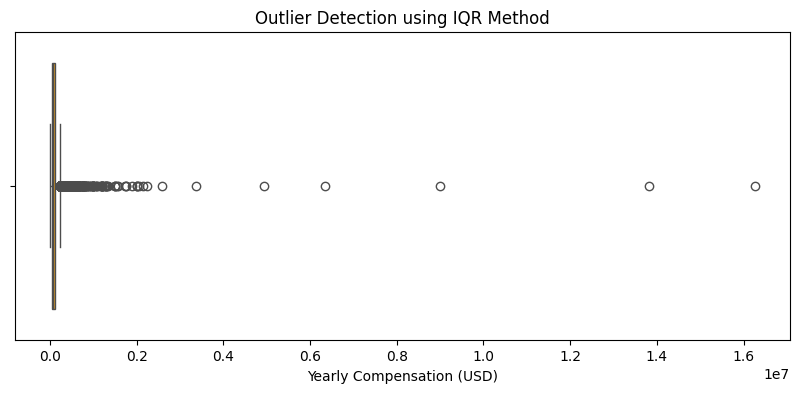

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
sns.boxplot(x=df["ConvertedCompYearly"], color="orange")

plt.title("Outlier Detection using IQR Method")
plt.xlabel("Yearly Compensation (USD)")
plt.show()


Pada grafik kamu terlihat:

Sebuah box (kotak kecil di kiri) → ini mewakili mayoritas data kompensasi tahunan (gaji).

Banyak titik di luar box (ke kanan jauh) → itu adalah nilai yang jauh lebih tinggi dari mayoritas — itulah outlier.

Sumbu X (Yearly Compensation) meluas sampai sekitar 1.6 × 10⁷ (≈16 juta USD) → 
artinya ada beberapa data gaji yang sangat besar, tidak wajar untuk dataset developer biasa.

Jadi secara visual, deteksi outlier-nya benar, karena memang nilai ekstrem tersebut keluar jauh dari distribusi utama

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [17]:
#batas bawah dan batas atas di step sebelumnya 

Q1 = df["ConvertedCompYearly"].quantile(0.25)
Q3 = df["ConvertedCompYearly"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound:,.2f}")
print(f"Upper Bound: {upper_bound:,.2f}")


Lower Bound: -80,177.25
Upper Bound: 220,860.75


In [18]:
#Buat DataFrame baru tanpa outlier

#Gunakan filtering condition untuk menyaring hanya data dalam batas normal.

df_no_outliers = df[
    (df["ConvertedCompYearly"] >= lower_bound) &
    (df["ConvertedCompYearly"] <= upper_bound)
].copy()


#✅ Penjelasan:

#>= lower_bound → hanya ambil data di atas batas bawah

#<= upper_bound → hanya ambil data di bawah batas atas

#.copy() → membuat salinan baru agar tidak mengubah DataFrame asli

In [19]:
#Validasi ukuran DataFrame baru

#Bandingkan jumlah baris sebelum dan sesudah penghapusan outlier.

print(f"Jumlah data asli: {len(df)}")
print(f"Jumlah data setelah menghapus outlier: {len(df_no_outliers)}")
print(f"Data yang dihapus (outlier): {len(df) - len(df_no_outliers)}")


# Interpretasi:

#Kalau dataset awal punya 60.000 baris, dan setelah pembersihan tinggal 57.000 → 
#berarti sekitar 3.000 data (5%) terdeteksi sebagai outlier.

Jumlah data asli: 65437
Jumlah data setelah menghapus outlier: 22457
Data yang dihapus (outlier): 42980


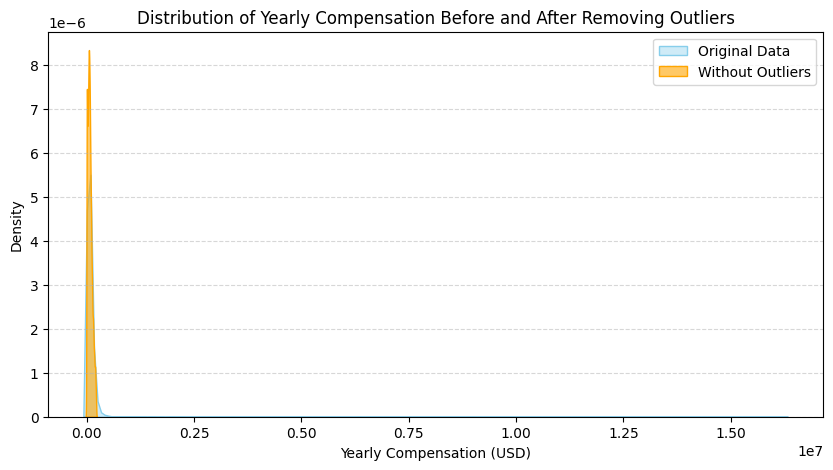

In [20]:
#Cek distribusi ulang untuk memastikan normalitas

#Visualisasi kembali distribusi data gaji tanpa outlier.

#import matplotlib.pyplot as plt
#import seaborn as sns

plt.figure(figsize=(10,5))
sns.kdeplot(df["ConvertedCompYearly"], label="Original Data", fill=True, color="skyblue", alpha=0.4)
sns.kdeplot(df_no_outliers["ConvertedCompYearly"], label="Without Outliers", fill=True, color="orange", alpha=0.6)
plt.title("Distribution of Yearly Compensation Before and After Removing Outliers")
plt.xlabel("Yearly Compensation (USD)")
plt.ylabel("Density")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [21]:
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70
}

df["Age_Num"] = df["Age"].map(age_map)


In [23]:
#replace numeric misal less than 1 year ke numeric 0.5 dan more than 50 years diganti numeric 51
#tipe diganti float
pd.to_numeric(df["YearsCodePro"], errors="coerce")
df["YearsCodePro"] = (
    df["YearsCodePro"]
    .replace("Less than 1 year", "0.5")
    .replace("More than 50 years", "51")
    .astype(float)
)


In [24]:
#Step 2: Select Numeric Columns for Correlation

#We’ll only include columns that make sense for correlation, such as:

#Age_Num

#YearsCodePro

#JobSatPoints_1 or numeric job satisfaction score

#ConvertedCompYearly

numeric_cols = ["Age_Num", "YearsCodePro", "JobSatPoints_1", "ConvertedCompYearly"]
corr_df = df[numeric_cols].corr()
print(corr_df)

                      Age_Num  YearsCodePro  JobSatPoints_1  \
Age_Num              1.000000      0.835504       -0.028206   
YearsCodePro         0.835504      1.000000       -0.028467   
JobSatPoints_1      -0.028206     -0.028467        1.000000   
ConvertedCompYearly  0.120809      0.140890        0.020306   

                     ConvertedCompYearly  
Age_Num                         0.120809  
YearsCodePro                    0.140890  
JobSatPoints_1                  0.020306  
ConvertedCompYearly             1.000000  


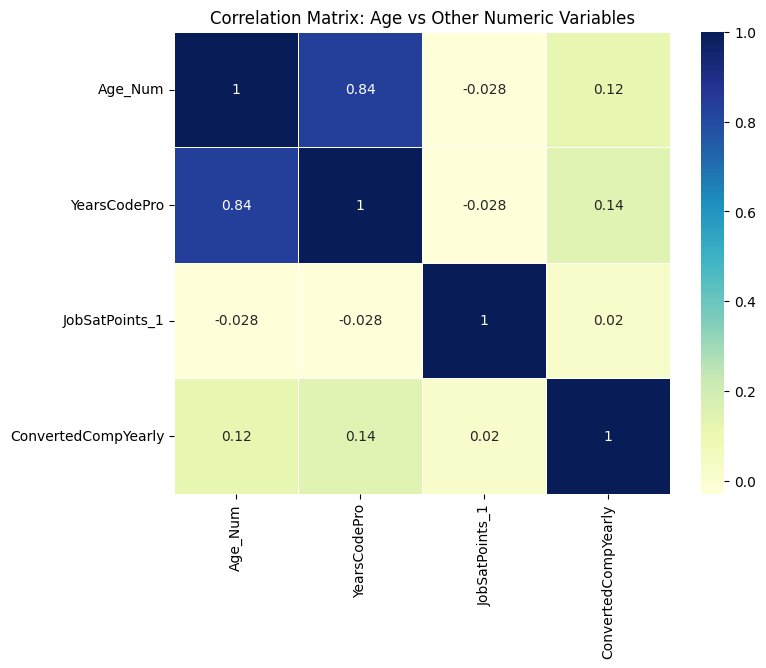

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap="YlGnBu", linewidths=0.5)
plt.title("Correlation Matrix: Age vs Other Numeric Variables")
plt.show()


<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.
